<a href="https://colab.research.google.com/github/HarshiniThanish/Variational-Autoencoder-/blob/main/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.78MB/s]


Epoch [1/10] Loss: 9889552.54
Epoch [2/10] Loss: 7283858.35
Epoch [3/10] Loss: 6858558.84
Epoch [4/10] Loss: 6678592.73
Epoch [5/10] Loss: 6574722.47
Epoch [6/10] Loss: 6505369.69
Epoch [7/10] Loss: 6454702.73
Epoch [8/10] Loss: 6420316.64
Epoch [9/10] Loss: 6386610.47
Epoch [10/10] Loss: 6360220.69
Generated shape: torch.Size([16, 784])


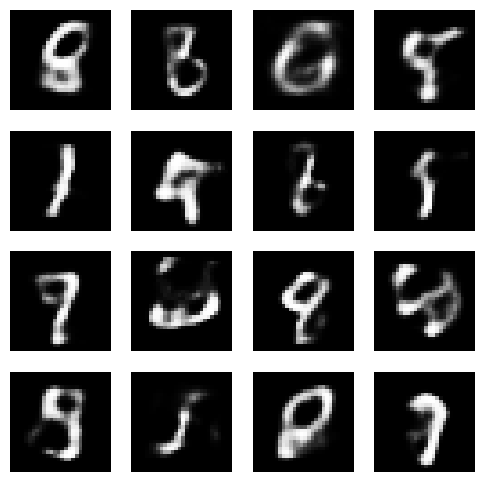

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt

#VAE MODEL

class VAE(nn.Module):

    def __init__(self,input_dim=784,hidden_dim=400,latent_dim=20):

        super().__init__()

        #Encoder

        self.fc1=nn.Linear(input_dim,hidden_dim)

        self.fc_mu=nn.Linear(hidden_dim,latent_dim)

        self.fc_logvar=nn.Linear(hidden_dim,latent_dim)

        #Decoder

        self.fc3=nn.Linear(latent_dim,hidden_dim)

        self.fc4=nn.Linear(hidden_dim,input_dim)


    def encode(self,x):

        h=F.relu(self.fc1(x))

        return self.fc_mu(h),self.fc_logvar(h)


    def reparameterize(self,mu,logvar):

        std=torch.exp(0.5*logvar)

        eps=torch.randn_like(std)

        return mu + eps * std


    def decode(self,z):

        h=F.relu(self.fc3(z))

        return torch.sigmoid(self.fc4(h))


    def forward(self,x):

        mu,logvar=self.encode(x.view(-1,784))

        z=self.reparameterize(mu,logvar)

        return self.decode(z),mu,logvar


#Loss Function

def vae_loss(recon_x,x,mu,logvar):

    BCE=F.binary_cross_entropy(

        recon_x,

        x.view(-1,784),

        reduction='sum'
    )

    KLD=-0.5 * torch.sum(

        1 + logvar - mu.pow(2) - logvar.exp()

    )

    return BCE + KLD


#Dataset

transform=transforms.ToTensor()

dataset=torchvision.datasets.MNIST(

    root="./data",

    train=True,

    transform=transform,

    download=True
)

loader=DataLoader(

    dataset,

    batch_size=128,

    shuffle=True
)


#Model

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae=VAE().to(device)

optimizer=optim.Adam(vae.parameters(),lr=0.001)


#Training

epochs=10

vae.train()

for i in range(epochs):

    total_loss=0

    for images,_ in loader:

        images=images.to(device)

        recon_images,mu,logvar=vae(images)

        loss=vae_loss(recon_images,images,mu,logvar)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{i+1}/{epochs}] Loss: {total_loss:.2f}")


#Generate New Images

vae.eval()

with torch.no_grad():

    z_sample=torch.randn(16,20).to(device)

    generated=vae.decode(z_sample).cpu()

print("Generated shape:",generated.shape)


#Visualization

generated_images=generated.view(16,28,28).numpy()

fig,axes=plt.subplots(4,4,figsize=(6,6))

for i,ax in enumerate(axes.flat):

    ax.imshow(generated_images[i],cmap='gray')

    ax.axis("off")

plt.show()